# Laboratorio 6 — Avance completo: actividades 1 a 4

## tl;dr

- Versión canónica y acumulativa del avance: integración, calidad, limpieza, EDA y red bipartita autor–video.
- La red completa contiene 625 nodos y 343 aristas cuyo peso total es 406 comentarios.
- La subred observada contiene 332 autores y 19 videos; otros 274 videos se conservan como falta de cobertura, no como aislamiento demostrado.
- Toda interpretación se limita a la muestra y evita confundir co-participación con amistad, respuesta o aprobación.

## Contexto y métodos

**Fuentes:** `youtube_videos.csv` y `youtube_comments.csv`, proporcionados para el Laboratorio 6.

El análisis preserva los archivos crudos y usa los identificadores de YouTube como llaves. Los nombres y *handles* se mantienen como etiquetas visibles, nunca como sustitutos de los ID. Todos los resultados se calculan desde los CSV al ejecutar el notebook.

### Supuestos clave

- Un valor vacío en `like_count_text` representa cero likes mostrados en la interfaz al recolectar los datos.
- Los conteos son una fotografía del momento de recolección, no valores históricos definitivos.
- `reply_count` no permite crear relaciones entre autores porque no identifica quién respondió.
- Un video sin comentarios en el archivo no se considera socialmente aislado: puede ser una ausencia de cobertura.

## Datos

### 1. Preparar el entorno y localizar las fuentes

In [1]:
from pathlib import Path
import json
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")

def encontrar_raiz(inicio: Path) -> Path:
    for candidato in (inicio, *inicio.parents):
        if (candidato / "youtube_videos.csv").exists() and (candidato / "youtube_comments.csv").exists():
            return candidato
    raise FileNotFoundError("No se encontraron los CSV del laboratorio en el directorio actual ni en sus padres.")

ROOT = encontrar_raiz(Path.cwd().resolve())
TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR = ROOT / "outputs" / "figures"
GRAPH_DIR = ROOT / "outputs" / "graphs"
PROCESSED_DIR = ROOT / "data" / "processed"
for directorio in (TABLE_DIR, FIGURE_DIR, GRAPH_DIR, PROCESSED_DIR):
    directorio.mkdir(parents=True, exist_ok=True)

BLUE = "#2378B7"
ORANGE = "#E07A1F"
GOLD = "#D7A928"
CHARCOAL = "#263238"
LIGHT_BLUE = "#A9D2EA"

print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Data Science\Lab6DataScience


### 2. Cargar los CSV preservando los identificadores

In [2]:
video_id_columns = ["video_id", "channel_id", "channel_handle", "owner_handle"]
comment_id_columns = ["video_id", "comment_id", "channel_id", "author_channel_id", "author_handle"]

videos_raw = pd.read_csv(
    ROOT / "youtube_videos.csv",
    encoding="utf-8-sig",
    dtype={column: "string" for column in video_id_columns},
)
comments_raw = pd.read_csv(
    ROOT / "youtube_comments.csv",
    encoding="utf-8-sig",
    dtype={column: "string" for column in comment_id_columns},
)

assert videos_raw.shape == (293, 20), f"Dimensión inesperada en videos: {videos_raw.shape}"
assert comments_raw.shape == (406, 17), f"Dimensión inesperada en comentarios: {comments_raw.shape}"

display(pd.DataFrame({
    "dataset": ["youtube_videos.csv", "youtube_comments.csv"],
    "filas": [len(videos_raw), len(comments_raw)],
    "columnas": [videos_raw.shape[1], comments_raw.shape[1]],
    "unidad_de_observacion": ["Un video", "Un comentario principal"],
    "llave_primaria": ["video_id", "comment_id"],
}))

,dataset,filas,columnas,unidad_de_observacion,llave_primaria
0,youtube_videos.csv,293,20,Un video,video_id
1,youtube_comments.csv,406,17,Un comentario principal,comment_id


### 3. Unidad de observación y relaciones

| Entidad | Identificador | Relación relevante |
|---|---|---|
| Canal propietario | `channel_id` | Publica uno o más videos. `channel_name` y `channel_handle` son etiquetas. |
| Video | `video_id` | Pertenece a un canal, tiene categoría y fue recuperado por una consulta. |
| Autor | `author_channel_id` | Puede publicar comentarios en uno o más videos. |
| Comentario | `comment_id` | Pertenece a un video mediante `video_id`. |
| Categoría | `category` | Clasificación asignada por YouTube al video. |
| Consulta | `source_query` / `query_hits` | Describe el muestreo; no equivale necesariamente al tema definitivo. |

La relación entre videos y comentarios es **uno a muchos**: un video puede tener varios comentarios, pero cada comentario pertenece a un solo `video_id`.

## Resultados — Actividades 1 y 2.1–2.4

### 4. Normalización conservadora y conversión de conteos

In [3]:
def normalizar_id(series: pd.Series) -> pd.Series:
    # Elimina espacios externos sin cambiar mayúsculas ni el contenido del ID.
    return series.astype("string").str.strip()

def normalizar_etiqueta(series: pd.Series) -> pd.Series:
    # Normaliza Unicode y espacios en nombres visibles, preservando tildes y capitalización.
    def transformar(value):
        if pd.isna(value):
            return pd.NA
        return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(value))).strip()
    return series.map(transformar).astype("string")

def parsear_conteo(value, *, vacio_como_cero=False):
    # Convierte enteros, separadores de miles y abreviaturas K/M; inválidos -> pd.NA.
    if pd.isna(value) or str(value).strip() == "":
        return 0 if vacio_como_cero else pd.NA
    text = unicodedata.normalize("NFKC", str(value)).lower().strip()
    text = re.sub(r"\b(vistas?|likes?|me gusta)\b", "", text).strip().replace(" ", "")
    abbreviated = re.fullmatch(r"(\d+(?:[.,]\d+)?)([km])", text)
    if abbreviated:
        number = float(abbreviated.group(1).replace(",", "."))
        multiplier = 1_000 if abbreviated.group(2) == "k" else 1_000_000
        return int(round(number * multiplier))
    if re.fullmatch(r"\d{1,3}(?:[.,]\d{3})+", text):
        return int(text.replace(",", "").replace(".", ""))
    if re.fullmatch(r"\d+", text):
        return int(text)
    return pd.NA

def parsear_lista_json(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    try:
        parsed = json.loads(str(value))
    except json.JSONDecodeError:
        return []
    return parsed if isinstance(parsed, list) else []

videos = videos_raw.copy()
comments = comments_raw.copy()

for column in ["video_id", "channel_id"]:
    videos[column] = normalizar_id(videos[column])
for column in ["video_id", "comment_id", "channel_id", "author_channel_id"]:
    comments[column] = normalizar_id(comments[column])
for column in ["channel_name", "channel_handle", "owner_handle"]:
    videos[column] = normalizar_etiqueta(videos[column])
for column in ["channel_name", "author_name", "author_handle"]:
    comments[column] = normalizar_etiqueta(comments[column])

videos["query_hits_lista"] = videos["query_hits"].map(parsear_lista_json)
videos["keywords_lista"] = videos["keywords"].map(parsear_lista_json)
videos["publish_datetime_utc"] = pd.to_datetime(videos["publish_date"], errors="coerce", utc=True)
videos["upload_datetime_utc"] = pd.to_datetime(videos["upload_date"], errors="coerce", utc=True)
videos["view_count_from_text"] = videos["view_count_text"].map(parsear_conteo).astype("Int64")
comments["like_count"] = comments["like_count_text"].map(
    lambda value: parsear_conteo(value, vacio_como_cero=True)
).astype("Int64")

parser_tests = {
    "vacío": parsear_conteo(" ", vacio_como_cero=True),
    "separador_coma": parsear_conteo("1,234"),
    "separador_punto": parsear_conteo("1.234"),
    "abreviatura_k": parsear_conteo("1.2K"),
    "abreviatura_m": parsear_conteo("2,5M"),
    "inválido": parsear_conteo("sin dato"),
}
assert parser_tests["vacío"] == 0
assert parser_tests["separador_coma"] == 1234
assert parser_tests["separador_punto"] == 1234
assert parser_tests["abreviatura_k"] == 1200
assert parser_tests["abreviatura_m"] == 2_500_000
assert pd.isna(parser_tests["inválido"])
parser_tests

{'vacío': 0,
 'separador_coma': 1234,
 'separador_punto': 1234,
 'abreviatura_k': 1200,
 'abreviatura_m': 2500000,
 'inválido': <NA>}

### 5. Perfil de calidad

In [4]:
def contar_atipicos_iqr(series: pd.Series):
    if not pd.api.types.is_numeric_dtype(series.dtype) or pd.api.types.is_bool_dtype(series.dtype):
        return pd.NA
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return 0
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((values < lower) | (values > upper)).sum())

def perfilar_dataset(name: str, frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for column in frame.columns:
        series = frame[column]
        blank_count = 0
        if pd.api.types.is_string_dtype(series.dtype) or series.dtype == object:
            blank_count = int(series.fillna("").astype(str).str.strip().eq("").sum())
        rows.append({
            "dataset": name,
            "variable": column,
            "tipo": str(series.dtype),
            "faltantes": int(series.isna().sum()),
            "faltantes_pct": round(float(series.isna().mean() * 100), 2),
            "vacios_texto": blank_count,
            "valores_unicos": int(series.nunique(dropna=True)),
            "constante": bool(series.nunique(dropna=False) <= 1),
            "atipicos_iqr": contar_atipicos_iqr(series),
        })
    return pd.DataFrame(rows)

diagnostico_calidad = pd.concat([
    perfilar_dataset("videos", videos_raw),
    perfilar_dataset("comentarios", comments_raw),
], ignore_index=True)

resumen_calidad = pd.DataFrame({
    "dataset": ["videos", "comentarios"],
    "filas": [len(videos_raw), len(comments_raw)],
    "duplicados_exactos": [int(videos_raw.duplicated().sum()), int(comments_raw.duplicated().sum())],
    "llaves_duplicadas": [int(videos_raw["video_id"].duplicated().sum()), int(comments_raw["comment_id"].duplicated().sum())],
    "llaves_nulas": [int(videos_raw["video_id"].isna().sum()), int(comments_raw["comment_id"].isna().sum())],
})
display(resumen_calidad)
display(diagnostico_calidad.query("faltantes > 0 or vacios_texto > 0 or constante == True"))

,dataset,filas,duplicados_exactos,llaves_duplicadas,llaves_nulas
0,videos,293,0,0,0
1,comentarios,406,0,0,0


,dataset,variable,tipo,faltantes,faltantes_pct,vacios_texto,valores_unicos,constante,atipicos_iqr
8,videos,published_time,str,13,4.44,13,80,False,<NA>
9,videos,view_count_text,str,13,4.44,13,259,False,<NA>
10,videos,description_snippet,str,25,8.53,25,236,False,<NA>
14,videos,description,str,26,8.87,26,234,False,<NA>
33,comentarios,like_count_text,str,0,0.00,189,31,False,<NA>
35,comentarios,is_pinned,bool,0,0.00,0,1,True,<NA>
36,comentarios,viewer_rating,float64,406,100.00,0,0,True,0


### 6. Consistencia de IDs, nombres, handles y campos redundantes

In [5]:
def ids_con_multiples_etiquetas(frame, id_column, label_column):
    counts = frame.dropna(subset=[id_column]).groupby(id_column)[label_column].nunique(dropna=True)
    return int((counts > 1).sum())

consistency_checks = pd.DataFrame([
    {"regla": "channel_id -> un channel_name (videos)", "incumplimientos": ids_con_multiples_etiquetas(videos, "channel_id", "channel_name")},
    {"regla": "channel_id -> un channel_handle", "incumplimientos": ids_con_multiples_etiquetas(videos, "channel_id", "channel_handle")},
    {"regla": "author_channel_id -> un author_name", "incumplimientos": ids_con_multiples_etiquetas(comments, "author_channel_id", "author_name")},
    {"regla": "author_channel_id -> un author_handle", "incumplimientos": ids_con_multiples_etiquetas(comments, "author_channel_id", "author_handle")},
    {"regla": "channel_handle == owner_handle", "incumplimientos": int((videos["channel_handle"].fillna("") != videos["owner_handle"].fillna("")).sum())},
    {"regla": "publish_date == upload_date", "incumplimientos": int((videos["publish_date"].fillna("") != videos["upload_date"].fillna("")).sum())},
    {"regla": "fechas de publicación válidas", "incumplimientos": int(videos["publish_datetime_utc"].isna().sum())},
    {"regla": "query_hits parseable como lista", "incumplimientos": int(videos["query_hits_lista"].map(type).ne(list).sum())},
    {"regla": "keywords parseable como lista", "incumplimientos": int(videos["keywords_lista"].map(type).ne(list).sum())},
])

replacement_character_rows = {
    column: int(videos_raw[column].fillna("").astype(str).str.contains("�", regex=False).sum())
    for column in videos_raw.select_dtypes(include=["object", "string"]).columns
    if videos_raw[column].fillna("").astype(str).str.contains("�", regex=False).any()
}
display(consistency_checks)
print("Filas con carácter de reemplazo Unicode:", replacement_character_rows)

,regla,incumplimientos
0,channel_id -> un channel_name (videos),0
1,channel_id -> un channel_handle,0
2,author_channel_id -> un author_name,0
3,author_channel_id -> un author_handle,0
4,channel_handle == owner_handle,0
5,publish_date == upload_date,0
6,fechas de publicación válidas,0
7,query_hits parseable como lista,0
8,keywords parseable como lista,0


Filas con carácter de reemplazo Unicode: {'description': 1}


### 7. Integración mediante `video_id` y cobertura

In [6]:
video_dimension = videos[[
    "video_id", "title", "channel_id", "channel_name", "channel_handle",
    "category", "source_group", "view_count", "publish_datetime_utc"
]].rename(columns={
    "title": "catalog_video_title",
    "channel_id": "catalog_channel_id",
    "channel_name": "catalog_channel_name",
    "channel_handle": "catalog_channel_handle",
    "source_group": "catalog_source_group",
})

comments_integrated = comments.merge(
    video_dimension,
    on="video_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)
matched_comments = int(comments_integrated["_merge"].eq("both").sum())
orphan_comments = int(comments_integrated["_merge"].eq("left_only").sum())
videos_with_comments = int(videos["video_id"].isin(comments["video_id"]).sum())
videos_without_comments = int(len(videos) - videos_with_comments)

assert len(comments_integrated) == len(comments) == 406
assert matched_comments == 406 and orphan_comments == 0
assert comments_integrated["channel_id"].equals(comments_integrated["catalog_channel_id"])

integration_report = pd.DataFrame({
    "métrica": ["Comentarios totales", "Comentarios asociados", "Comentarios huérfanos", "Videos con comentarios recolectados", "Videos sin comentarios recolectados"],
    "valor": [len(comments), matched_comments, orphan_comments, videos_with_comments, videos_without_comments],
})
display(integration_report)

,métrica,valor
0,Comentarios totales,406
1,Comentarios asociados,406
2,Comentarios huérfanos,0
3,Videos con comentarios recolectados,19
4,Videos sin comentarios recolectados,274


### 8. Hallazgos y tratamiento de variables problemáticas

In [7]:
blank_likes = int(comments_raw["like_count_text"].fillna("").astype(str).str.strip().eq("").sum())
issues = pd.DataFrame([
    ["viewer_rating", "406/406 faltantes", "Alta", "Excluir del análisis; conservar en datos crudos."],
    ["is_pinned", "Constante False", "Baja", "No aporta variación; conservar para auditoría."],
    ["published_time", f"{int(videos_raw['published_time'].isna().sum())} faltantes y formato relativo", "Media", "Usar publish_date en UTC para análisis temporal."],
    ["view_count_text", f"{int(videos_raw['view_count_text'].isna().sum())} faltantes", "Baja", "Usar view_count; conservar el texto para auditoría."],
    ["like_count_text", f"{blank_likes} vacíos", "Media", "Convertir vacíos a cero y guardar like_count numérico."],
    ["upload_date", "Coincide con publish_date en todos los registros", "Baja", "Evitar análisis redundante; preservar ambas columnas crudas."],
    ["owner_handle", "Coincide con channel_handle", "Baja", "Usar channel_id como llave y handle solo como etiqueta."],
    ["description", "Una fila contiene �", "Media", "No inventar el carácter perdido; señalar el defecto de origen."],
    ["cobertura de comentarios", f"Solo {videos_with_comments}/293 videos tienen comentarios", "Alta", "No generalizar participación a todo el catálogo."],
], columns=["variable_o_riesgo", "evidencia", "severidad", "tratamiento"])
display(issues)

diagnostico_calidad.to_csv(TABLE_DIR / "diagnostico_calidad.csv", index=False, encoding="utf-8-sig")
assert (TABLE_DIR / "diagnostico_calidad.csv").exists()
print("Exportado:", TABLE_DIR / "diagnostico_calidad.csv")

,variable_o_riesgo,evidencia,severidad,tratamiento
0,viewer_rating,406/406 faltantes,Alta,Excluir del análisis; conservar en datos crudos.
1,is_pinned,Constante False,Baja,No aporta variación; conservar para auditoría.
2,published_time,13 faltantes y formato relativo,Media,Usar publish_date en UTC para análisis temporal.
3,view_count_text,13 faltantes,Baja,Usar view_count; conservar el texto para auditoría.
4,like_count_text,189 vacíos,Media,Convertir vacíos a cero y guardar like_count numérico.
5,upload_date,Coincide con publish_date en todos los registros,Baja,Evitar análisis redundante; preservar ambas columnas crudas.
6,owner_handle,Coincide con channel_handle,Baja,Usar channel_id como llave y handle solo como etiqueta.
7,description,Una fila contiene �,Media,No inventar el carácter perdido; señalar el defecto de origen.
8,cobertura de comentarios,Solo 19/293 videos tienen comentarios,Alta,No generalizar participación a todo el catálogo.


Exportado: C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Data Science\Lab6DataScience\outputs\tables\diagnostico_calidad.csv


### Conclusiones del primer hito

La integración es completa y no produce explosión de filas. Las llaves son utilizables y consistentes. El principal riesgo no es la integridad de la unión, sino la cobertura: solo una selección pequeña de videos tiene comentarios recolectados. Los valores atípicos en conteos se conservan porque representan popularidad real o concentración potencial, no errores demostrados.

## Resultados — Actividades 2.5–2.7 y 3

### 9. Construir `texto_original` y `texto_limpio`

In [8]:
import spacy

try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except OSError as exc:
    raise RuntimeError(
        "Falta el modelo español. Ejecute: python -m spacy download es_core_news_sm"
    ) from exc

URL_RE = re.compile(r"(?:https?://|www\.)\S+", re.IGNORECASE)
HASHTAG_RE = re.compile(r"(?<!\w)#([\wáéíóúüñÁÉÍÓÚÜÑ]+)", re.UNICODE)
MENTION_RE = re.compile(r"(?<!\w)@([\w.\-]+)", re.UNICODE)

def extraer_emojis(text):
    return [character for character in str(text) if unicodedata.category(character) in {"So", "Sk"}]

def preparar_para_spacy(text):
    normalized = unicodedata.normalize("NFKC", str(text)).lower()
    hashtags = HASHTAG_RE.findall(normalized)
    mentions = MENTION_RE.findall(normalized)
    emojis = extraer_emojis(normalized)
    normalized = URL_RE.sub(" ", normalized)
    normalized = HASHTAG_RE.sub(r" \1 ", normalized)  # conserva la palabra del hashtag
    normalized = MENTION_RE.sub(" ", normalized)      # elimina el identificador mencionado
    normalized = "".join(
        " " if unicodedata.category(character)[0] in {"P", "S"} else character
        for character in normalized
    )
    normalized = re.sub(r"\b\d+\b", " ", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return normalized, hashtags, mentions, emojis

def limpiar_textos(series: pd.Series) -> pd.DataFrame:
    prepared = [preparar_para_spacy(value if not pd.isna(value) else "") for value in series]
    docs = nlp.pipe((item[0] for item in prepared), batch_size=64)
    cleaned = []
    for doc in docs:
        lemmas = []
        for token in doc:
            lemma = (token.lemma_ or token.text).lower().strip()
            if token.is_alpha and not token.is_stop and len(lemma) > 2:
                lemmas.append(lemma)
        cleaned.append(" ".join(lemmas))
    return pd.DataFrame({
        "texto_limpio": cleaned,
        "hashtags_lista": [item[1] for item in prepared],
        "menciones_lista": [item[2] for item in prepared],
        "emojis_lista": [item[3] for item in prepared],
    }, index=series.index)

comments_clean = comments.copy()
comments_clean["texto_original"] = comments_raw["text"].astype("string")
comment_text_features = limpiar_textos(comments_clean["texto_original"])
comments_clean = pd.concat([comments_clean, comment_text_features], axis=1)
comments_clean["hashtags"] = comments_clean["hashtags_lista"].map(lambda values: json.dumps(values, ensure_ascii=False))
comments_clean["menciones"] = comments_clean["menciones_lista"].map(lambda values: json.dumps(values, ensure_ascii=False))
comments_clean["emojis"] = comments_clean["emojis_lista"].map(lambda values: json.dumps(values, ensure_ascii=False))
comments_clean["texto_modificado"] = comments_clean["texto_original"].fillna("").ne(comments_clean["texto_limpio"])
comments_clean["texto_vacio"] = comments_clean["texto_limpio"].str.strip().eq("")
comments_clean["duplicado_texto_original"] = comments_clean["texto_original"].duplicated(keep=False)
comments_clean["duplicado_normalizado"] = comments_clean["texto_limpio"].duplicated(keep=False)

videos_clean = videos.copy()
videos_clean["contenido_original"] = (
    videos_clean["title"].fillna("") + ". " +
    videos_clean["description"].fillna("") + " " +
    videos_clean["keywords_lista"].map(lambda values: " ".join(map(str, values)))
)
video_text_features = limpiar_textos(videos_clean["contenido_original"])
videos_clean["contenido_limpio"] = video_text_features["texto_limpio"]
videos_clean["hashtags_contenido_lista"] = video_text_features["hashtags_lista"]

assert len(comments_clean) == 406
assert np.array_equal(
    comments_clean["texto_original"].fillna("").to_numpy(),
    comments_raw["text"].astype("string").fillna("").to_numpy(),
)
assert not comments_clean["texto_limpio"].str.contains(URL_RE).any()
assert not comments_clean["texto_limpio"].str.contains(r"@\w+", regex=True).any()

### 10. Cuantificar el efecto de la limpieza

In [9]:
cleaning_effect = pd.DataFrame({
    "métrica": [
        "Registros originales", "Registros conservados", "Textos modificados",
        "Vacíos antes", "Vacíos después", "Filas en grupos duplicados antes",
        "Filas en grupos duplicados después"
    ],
    "valor": [
        len(comments_raw), len(comments_clean), int(comments_clean["texto_modificado"].sum()),
        int(comments_clean["texto_original"].fillna("").str.strip().eq("").sum()),
        int(comments_clean["texto_vacio"].sum()),
        int(comments_clean["duplicado_texto_original"].sum()),
        int(comments_clean["duplicado_normalizado"].sum()),
    ],
})
display(cleaning_effect)
display(comments_clean.loc[comments_clean["texto_vacio"], ["comment_id", "texto_original", "texto_limpio"]].head(10))

,métrica,valor
0,Registros originales,406
1,Registros conservados,406
2,Textos modificados,403
3,Vacíos antes,0
4,Vacíos después,9
5,Filas en grupos duplicados antes,4
6,Filas en grupos duplicados después,18


,comment_id,texto_original,texto_limpio
38,UgwIlv8gtF3WKYfHSJJ4AaABAg,😮,
49,UgwSDn5aIUEZwOlx9c94AaABAg,❤🎉,
97,UgwxjmtBoAozs0ZUAcd4AaABAg.AaAbqoGVGipAaAjNG9oPRN,que?,
112,Ugx74OPnWkWaFjpFuA94AaABAg.A7ki-1ED5b2A7nIcG2_svP,Cierto.,
129,UgxEE17R1iQyuDZebVF4AaABAg.A_UFk_pMAbMA_VZ_0Vdu89,😂😂,
139,UgxEsAK7q3l34wFdZ414AaABAg.A_zCnf5bSajAa0qEPC8tJc,​ @Murmullodelbarrio 👍🇬🇹,
187,UgxoLjEjkngSVGZvO1N4AaABAg,👏👏👏👏👏👏,
272,Ugy__nsWCBggw9EzOUd4AaABAg.A7lbRpGUZoHA7nJxaD37u-,Cierto.,
318,Ugz26waEPWK6VtsenFZ4AaABAg.ALglV0O_2mtALgq1_mUSB_,Ud y quienes mas😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂,


### 11. Métricas descriptivas y tablas de participación

In [10]:
comment_stats_video = comments_clean.groupby("video_id").agg(
    comments_observed=("comment_id", "size"),
    unique_authors=("author_channel_id", "nunique"),
    likes_observed=("like_count", "sum"),
    replies_observed=("reply_count", "sum"),
).reset_index()

video_eda = videos_clean.merge(comment_stats_video, on="video_id", how="left", validate="one_to_one")
count_columns = ["comments_observed", "unique_authors", "likes_observed", "replies_observed"]
video_eda[count_columns] = video_eda[count_columns].fillna(0).astype(int)

channel_video_stats = videos_clean.groupby("channel_id").agg(
    channel_name=("channel_name", "first"),
    videos=("video_id", "nunique"),
    views=("view_count", "sum"),
).reset_index()
channel_comment_stats = comments_clean.groupby("channel_id").agg(
    comments=("comment_id", "size"),
    authors=("author_channel_id", "nunique"),
).reset_index()
channel_eda = channel_video_stats.merge(channel_comment_stats, on="channel_id", how="left", validate="one_to_one")
channel_eda[["comments", "authors"]] = channel_eda[["comments", "authors"]].fillna(0).astype(int)

author_eda = comments_clean.groupby("author_channel_id").agg(
    author_name=("author_name", "first"),
    author_handle=("author_handle", "first"),
    comments=("comment_id", "size"),
    videos=("video_id", "nunique"),
    channels=("channel_id", "nunique"),
    likes=("like_count", "sum"),
    replies=("reply_count", "sum"),
).reset_index()

overview = pd.DataFrame({
    "métrica": ["Videos", "Canales", "Comentarios", "Autores", "Videos con comentarios", "Canales comentados"],
    "valor": [
        videos_clean["video_id"].nunique(), videos_clean["channel_id"].nunique(),
        len(comments_clean), comments_clean["author_channel_id"].nunique(),
        comments_clean["video_id"].nunique(), comments_clean["channel_id"].nunique(),
    ],
})
display(overview)
display(video_eda.nlargest(10, "comments_observed")[["video_id", "title", "channel_name", "comments_observed", "unique_authors", "view_count"]])
display(channel_eda.nlargest(10, "comments")[["channel_name", "videos", "comments", "authors", "views"]])

,métrica,valor
0,Videos,293
1,Canales,97
2,Comentarios,406
3,Autores,332
4,Videos con comentarios,19
5,Canales comentados,8


,video_id,title,channel_name,comments_observed,unique_authors,view_count
246,n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,128,11775
229,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,10156
38,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,32,11670
130,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,25,18,14200
136,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,19,3628
239,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,304089
289,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,16,1954
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,14,13,6692
250,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,10,717
197,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,PrensaLibreOficial,7,7,5469


,channel_name,videos,comments,authors,views
26,Quorum,18,256,214,31267
3,Gobierno de la República de Guatemala,32,70,50,56052
44,Noticias Telemundo,2,25,18,77449
54,Municipalidad de Guatemala,27,25,25,452548
50,Noti7,3,14,13,78000
28,PrensaLibreOficial,17,7,7,424888
87,TN23 Guatemala,7,7,7,67950
66,Noticiero Guatevisión 13 Hrs.,2,2,2,5411
0,México Poder,1,0,0,29736
1,Canal Antigua,5,0,0,3305


### 12. Hashtags, palabras y bigramas

In [11]:
def top_tokens(texts, n=15):
    return Counter(token for text in texts.fillna("") for token in text.split()).most_common(n)

def top_bigrams(texts, n=15):
    counter = Counter()
    for text in texts.fillna(""):
        tokens = text.split()
        counter.update(zip(tokens, tokens[1:]))
    return [(" ".join(pair), count) for pair, count in counter.most_common(n)]

comment_words = pd.DataFrame(top_tokens(comments_clean["texto_limpio"]), columns=["término", "frecuencia"])
comment_bigrams = pd.DataFrame(top_bigrams(comments_clean["texto_limpio"]), columns=["bigrama", "frecuencia"])
content_words = pd.DataFrame(top_tokens(videos_clean["contenido_limpio"]), columns=["término", "frecuencia"])
all_hashtags = [
    hashtag.lower()
    for values in comments_clean["hashtags_lista"] for hashtag in values
] + [
    hashtag.lower()
    for values in videos_clean["hashtags_contenido_lista"] for hashtag in values
]
hashtag_counts = pd.DataFrame(Counter(all_hashtags).most_common(15), columns=["hashtag", "frecuencia"])
query_counts = pd.DataFrame(
    Counter(query for values in videos_clean["query_hits_lista"] for query in values).most_common(15),
    columns=["consulta", "frecuencia"],
)

display(comment_words.head(10), comment_bigrams.head(10), hashtag_counts.head(10), query_counts.head(10))

,término,frecuencia
0,pueblo,56
1,guatemala,52
2,diputado,50
3,él,46
4,pagar,40
5,país,36
6,dinero,34
7,presidente,32
8,corrupto,30
9,trabajo,28


,bigrama,frecuencia
0,presidente bernardo,9
1,bernardo arevalo,8
2,ciudad guatemala,6
3,dar él,5
4,nery roda,5
5,pueblo pagar,5
6,bla bla,5
7,pagar sueldo,5
8,pacto corrupto,5
9,buscar trabajo,4


,hashtag,frecuencia
0,guatemala,48
1,larondagt,29
2,noticias,14
3,envivodca,12
4,nacionales,7
5,like,7
6,comenta,7
7,comparte,7
8,siguenos,7
9,protegeryservir,6


,consulta,frecuencia
0,Municipalidad de Guatemala,20
1,Gobierno de Guatemala,19
2,@GobiernodelaRepublicadeGuatema,18
3,@MunicipalidaddeGuatemala-1551,18
4,@GobiernodeGuatemala,17
5,guatemala noticias,16
6,Gobierno de la República de Guatemala,16
7,Ministerio de Comunicaciones Guatemala,16
8,Conred Guatemala,15
9,PMT Guatemala,15


### 13. Concentración, popularidad y participación

In [12]:
def concentration_rows(values: pd.Series, entity: str):
    ordered = values.sort_values(ascending=False)
    total = ordered.sum()
    return [
        {"entidad": entity, "top_n": n, "comentarios": int(ordered.head(n).sum()), "proporción": float(ordered.head(n).sum() / total)}
        for n in (1, 3, 5, 10) if n <= len(ordered)
    ]

concentration = pd.DataFrame(
    concentration_rows(video_eda.set_index("video_id")["comments_observed"], "video") +
    concentration_rows(channel_eda.set_index("channel_id")["comments"], "canal")
)
display(concentration.assign(proporción_pct=lambda frame: (frame["proporción"] * 100).round(2)))

all_video_spearman = video_eda[["view_count", "comments_observed"]].corr(method="spearman").iloc[0, 1]
commented_video_eda = video_eda.query("comments_observed > 0").copy()
commented_video_spearman = commented_video_eda[["view_count", "comments_observed"]].corr(method="spearman").iloc[0, 1]
correlation_report = pd.DataFrame({
    "población": ["Todos los videos", "Solo videos con comentarios recolectados"],
    "n": [len(video_eda), len(commented_video_eda)],
    "spearman_views_comments": [all_video_spearman, commented_video_spearman],
})
display(correlation_report)

,entidad,top_n,comentarios,proporción,proporción_pct
0,video,1,161,0.396552,39.66
1,video,3,256,0.630542,63.05
2,video,5,306,0.753695,75.37
3,video,10,380,0.935961,93.60
4,canal,1,256,0.630542,63.05
5,canal,3,351,0.864532,86.45
6,canal,5,390,0.960591,96.06
7,canal,10,406,1.000000,100.00


,población,n,spearman_views_comments
0,Todos los videos,293,0.080323
1,Solo videos con comentarios recolectados,19,0.811497


### 14. Visualizaciones cuantitativas

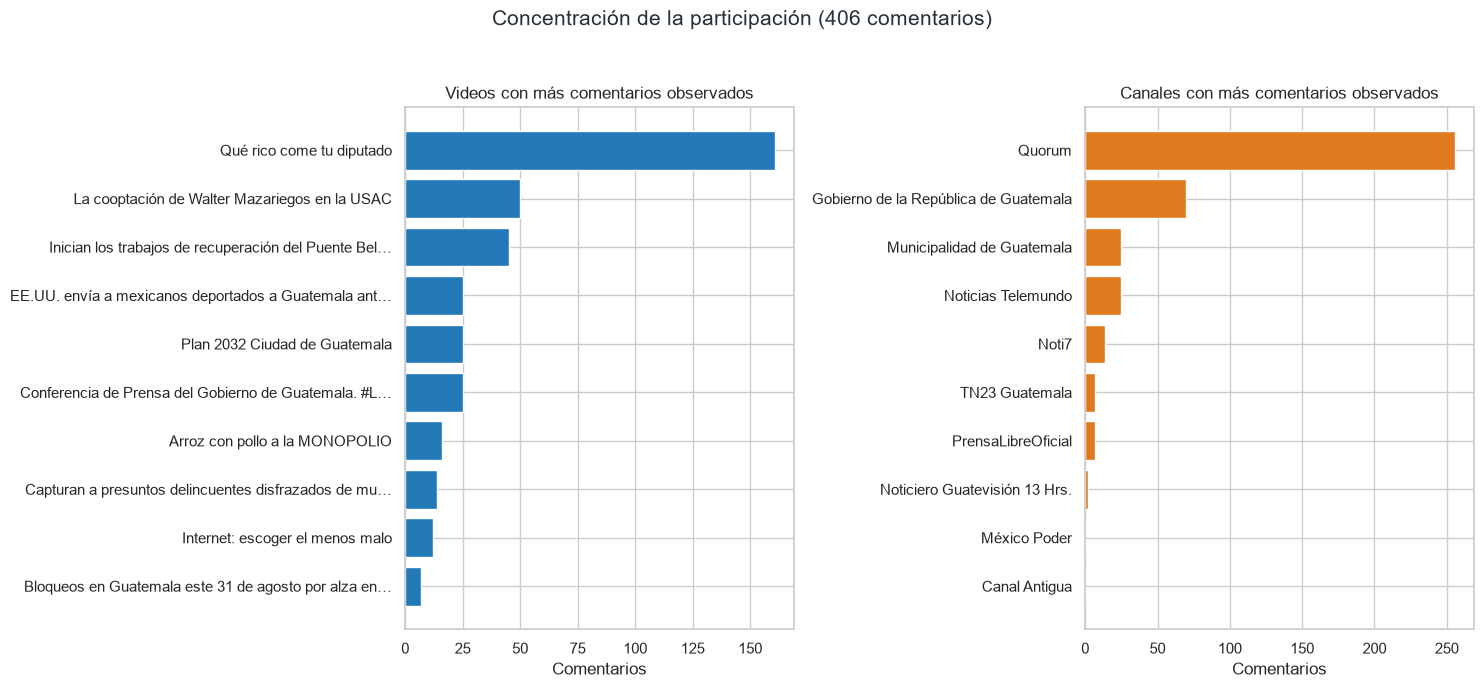

In [13]:
def shorten(value, width=52):
    value = str(value)
    return value if len(value) <= width else value[:width - 1] + "…"

top_videos = video_eda.nlargest(10, "comments_observed").sort_values("comments_observed")
top_channels = channel_eda.nlargest(10, "comments").sort_values("comments")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].barh(top_videos["title"].map(shorten), top_videos["comments_observed"], color=BLUE)
axes[0].set(title="Videos con más comentarios observados", xlabel="Comentarios", ylabel="")
axes[0].set_xlim(left=0)
axes[1].barh(top_channels["channel_name"].map(shorten), top_channels["comments"], color=ORANGE)
axes[1].set(title="Canales con más comentarios observados", xlabel="Comentarios", ylabel="")
axes[1].set_xlim(left=0)
fig.suptitle("Concentración de la participación (406 comentarios)", fontsize=15, color=CHARCOAL)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURE_DIR / "01_top_participacion.png", dpi=170, bbox_inches="tight")
plt.show()

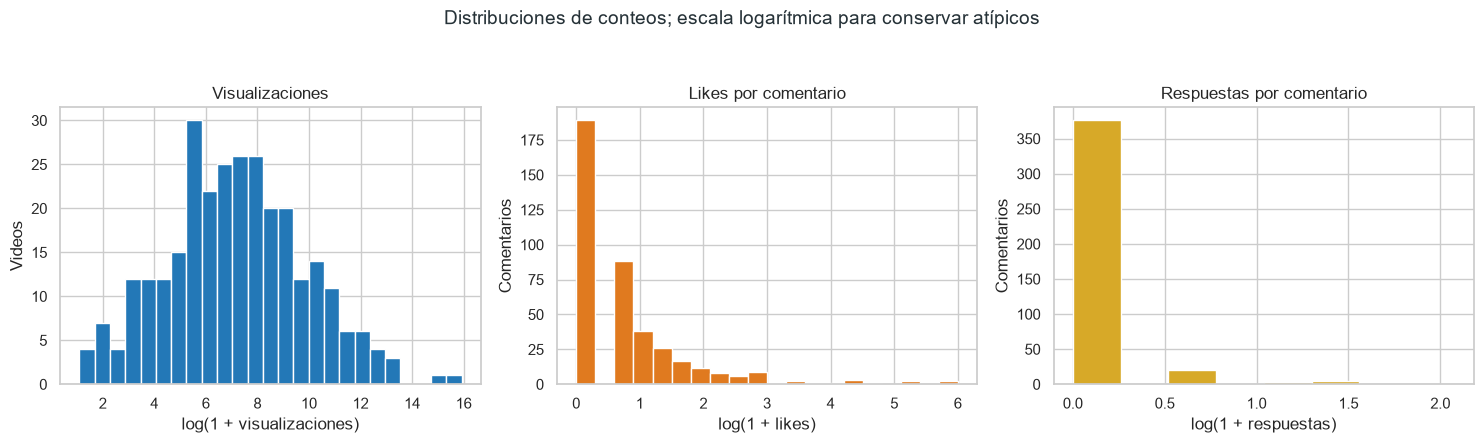

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(np.log1p(videos_clean["view_count"]), bins=25, color=BLUE, edgecolor="white")
axes[0].set(title="Visualizaciones", xlabel="log(1 + visualizaciones)", ylabel="Videos")
axes[1].hist(np.log1p(comments_clean["like_count"]), bins=20, color=ORANGE, edgecolor="white")
axes[1].set(title="Likes por comentario", xlabel="log(1 + likes)", ylabel="Comentarios")
axes[2].hist(np.log1p(comments_clean["reply_count"]), bins=8, color=GOLD, edgecolor="white")
axes[2].set(title="Respuestas por comentario", xlabel="log(1 + respuestas)", ylabel="Comentarios")
fig.suptitle("Distribuciones de conteos; escala logarítmica para conservar atípicos", fontsize=14, color=CHARCOAL)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURE_DIR / "02_distribuciones_conteos.png", dpi=170, bbox_inches="tight")
plt.show()

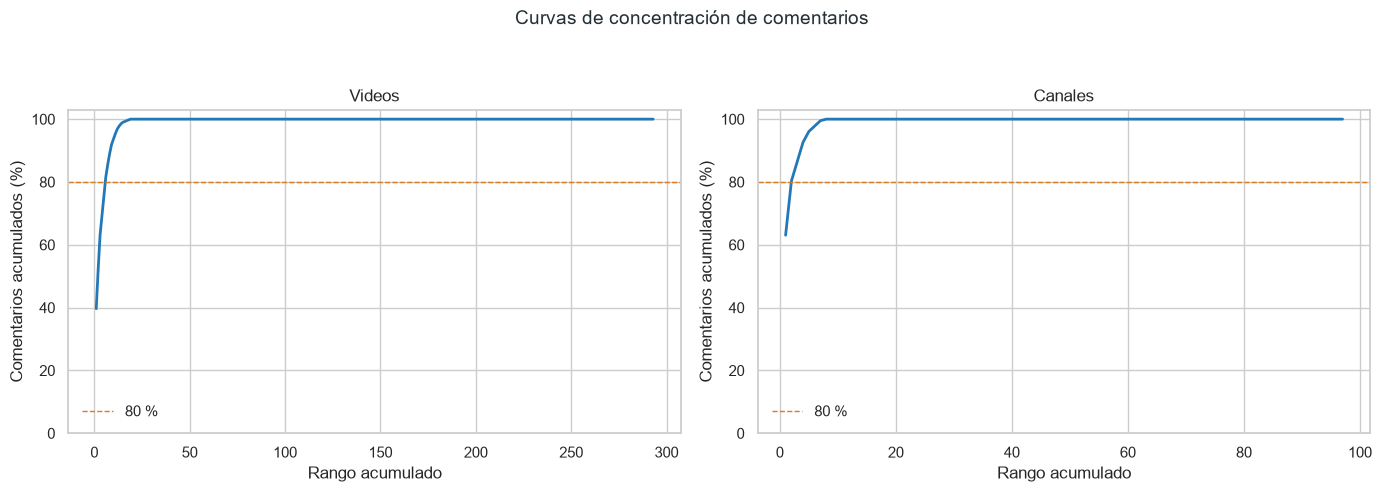

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, values, title in [
    (axes[0], video_eda["comments_observed"].sort_values(ascending=False), "Videos"),
    (axes[1], channel_eda["comments"].sort_values(ascending=False), "Canales"),
]:
    cumulative = values.cumsum() / values.sum() * 100
    axis.plot(range(1, len(cumulative) + 1), cumulative, color=BLUE, linewidth=2)
    axis.axhline(80, color=ORANGE, linestyle="--", linewidth=1, label="80 %")
    axis.set(title=title, xlabel="Rango acumulado", ylabel="Comentarios acumulados (%)", ylim=(0, 103))
    axis.legend(frameon=False)
fig.suptitle("Curvas de concentración de comentarios", fontsize=14, color=CHARCOAL)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURE_DIR / "03_concentracion_pareto.png", dpi=170, bbox_inches="tight")
plt.show()

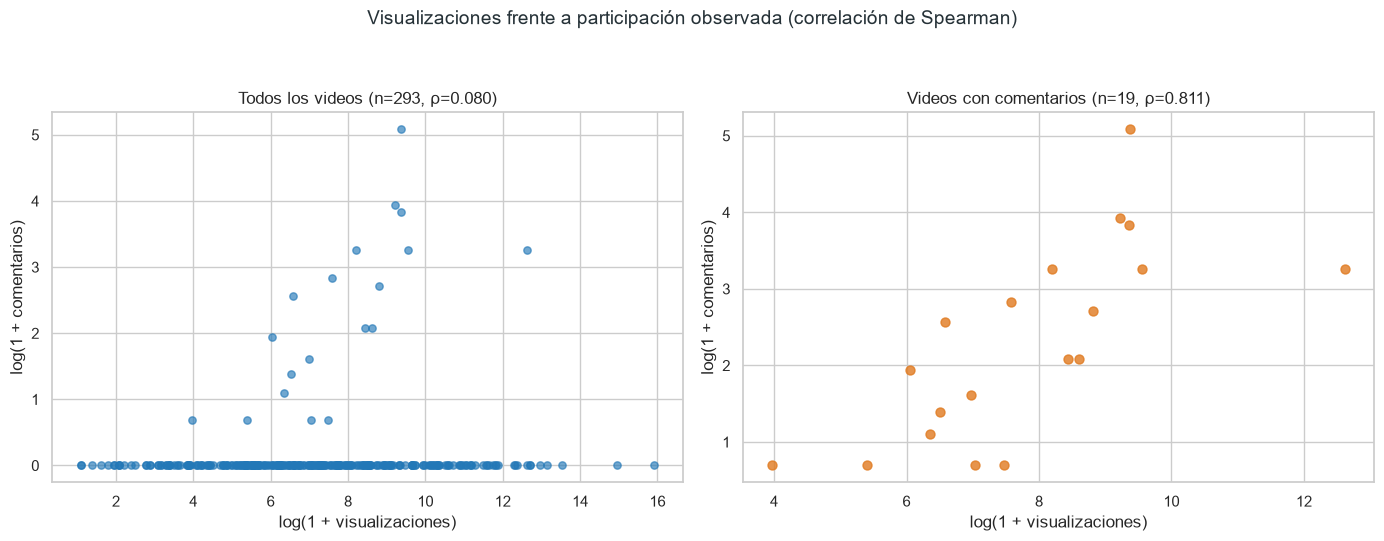

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(np.log1p(video_eda["view_count"]), np.log1p(video_eda["comments_observed"]), color=BLUE, alpha=0.65, s=28)
axes[0].set(
    title=f"Todos los videos (n={len(video_eda)}, ρ={all_video_spearman:.3f})",
    xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios)",
)
axes[1].scatter(np.log1p(commented_video_eda["view_count"]), np.log1p(commented_video_eda["comments_observed"]), color=ORANGE, alpha=0.8, s=42)
axes[1].set(
    title=f"Videos con comentarios (n={len(commented_video_eda)}, ρ={commented_video_spearman:.3f})",
    xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios)",
)
fig.suptitle("Visualizaciones frente a participación observada (correlación de Spearman)", fontsize=14, color=CHARCOAL)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURE_DIR / "04_visualizaciones_vs_comentarios.png", dpi=170, bbox_inches="tight")
plt.show()

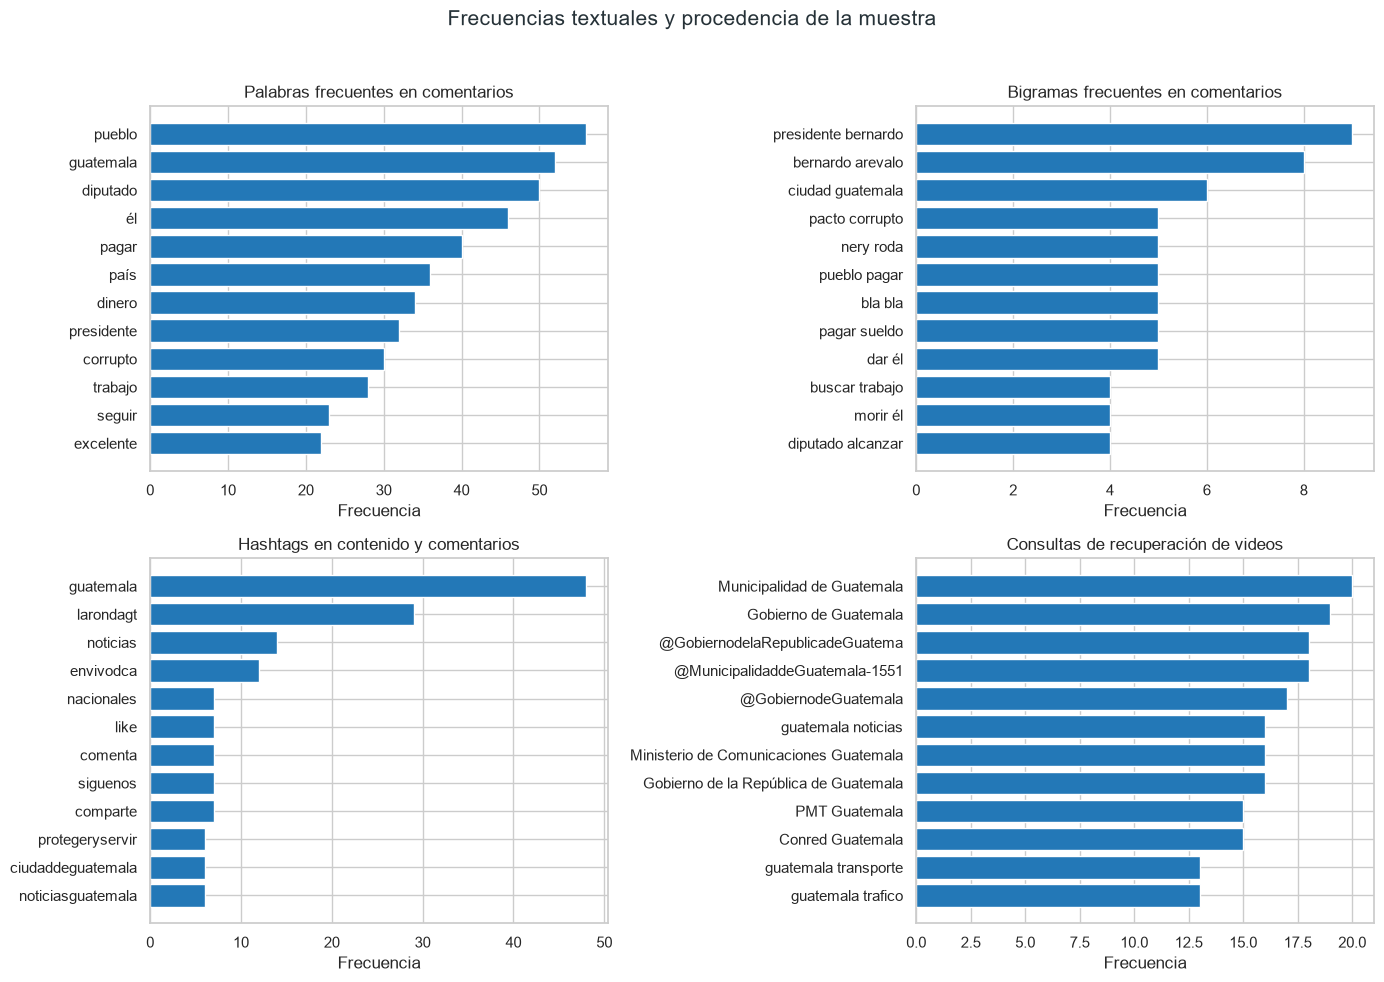

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
chart_specs = [
    (comment_words, "término", "frecuencia", "Palabras frecuentes en comentarios"),
    (comment_bigrams, "bigrama", "frecuencia", "Bigramas frecuentes en comentarios"),
    (hashtag_counts, "hashtag", "frecuencia", "Hashtags en contenido y comentarios"),
    (query_counts, "consulta", "frecuencia", "Consultas de recuperación de videos"),
]
for axis, (frame, label_column, value_column, title) in zip(axes.flat, chart_specs):
    shown = frame.head(12).sort_values(value_column)
    axis.barh(shown[label_column], shown[value_column], color=BLUE)
    axis.set(title=title, xlabel="Frecuencia", ylabel="", xlim=(0, None))
fig.suptitle("Frecuencias textuales y procedencia de la muestra", fontsize=15, color=CHARCOAL)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIGURE_DIR / "05_frecuencias_texto.png", dpi=170, bbox_inches="tight")
plt.show()

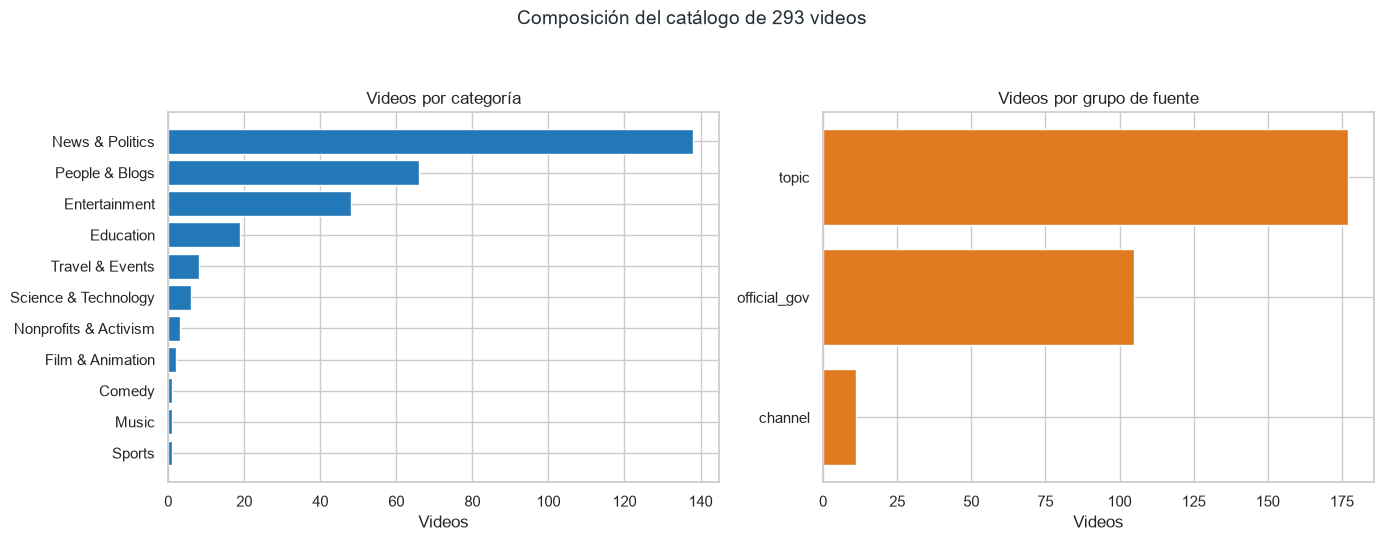

In [18]:
category_counts = videos_clean["category"].value_counts().sort_values()
source_counts = videos_clean["source_group"].value_counts().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(category_counts.index, category_counts.values, color=BLUE)
axes[0].set(title="Videos por categoría", xlabel="Videos", ylabel="", xlim=(0, None))
axes[1].barh(source_counts.index, source_counts.values, color=ORANGE)
axes[1].set(title="Videos por grupo de fuente", xlabel="Videos", ylabel="", xlim=(0, None))
fig.suptitle("Composición del catálogo de 293 videos", fontsize=14, color=CHARCOAL)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURE_DIR / "06_categorias_y_fuentes.png", dpi=170, bbox_inches="tight")
plt.show()

### 15. Preguntas obligatorias 3.5: evidencia preliminar

In [19]:
recurrent_authors = author_eda.query("videos > 1").sort_values(["channels", "videos", "comments"], ascending=False)
cross_channel_authors = author_eda.query("channels > 1").sort_values(["channels", "videos", "comments"], ascending=False)

def top_terms_for_video(video_id, n=6):
    texts = comments_clean.loc[comments_clean["video_id"].eq(video_id), "texto_limpio"]
    return ", ".join(term for term, _ in top_tokens(texts, n=n))

themes_top_videos = video_eda.nlargest(5, "comments_observed")[["video_id", "title", "channel_name", "comments_observed"]].copy()
themes_top_videos["términos_frecuentes"] = themes_top_videos["video_id"].map(top_terms_for_video)

observed_emojis = Counter(emoji for values in comments_clean["emojis_lista"] for emoji in values)
affective_terms = {
    "positivo": {"gracias", "bueno", "excelente", "feliz", "amor", "apoyo", "bendición", "bonito"},
    "negativo": {"mal", "malo", "odio", "triste", "corrupción", "mentira", "vergüenza", "problema"},
}
all_comment_terms = Counter(token for text in comments_clean["texto_limpio"] for token in text.split())
affective_observed = pd.DataFrame([
    {"referencia_exploratoria": label, "término": term, "frecuencia": all_comment_terms[term]}
    for label, terms in affective_terms.items() for term in sorted(terms) if all_comment_terms[term] > 0
]).sort_values("frecuencia", ascending=False)

display(themes_top_videos)
display(recurrent_authors.head(15))
print(f"Autores presentes en más de un video: {len(recurrent_authors)}")
print(f"Autores presentes en más de un canal: {len(cross_channel_authors)}")
print("Emojis/símbolos más observados:", observed_emojis.most_common(12))
display(affective_observed.head(15))

top_video = video_eda.nlargest(1, "comments_observed").iloc[0]
top_channel = channel_eda.nlargest(1, "comments").iloc[0]
display(Markdown(f'''
**Respuestas preliminares**

- **Concentración:** el video con mayor participación reúne {top_video['comments_observed']} comentarios; el canal líder reúne {top_channel['comments']} de 406.
- **Audiencias compartidas:** {len(recurrent_authors)} autores aparecen en más de un video y {len(cross_channel_authors)} cruzan canales. Esto prueba co-participación observada, no amistad ni conversación directa.
- **Puentes:** la recurrencia permite proponer candidatos; la comprobación estructural mediante puntos de articulación se añade en el notebook 03.
- **Temas:** la tabla anterior resume lemas frecuentes de los cinco videos con más comentarios.
- **Sentimiento:** los términos afectivos y emojis son solo señales descriptivas. No se asigna polaridad a comentarios ni se afirma el sentimiento de comunidades antes de los ejercicios 7 y 9.
- **Visibilidad y participación:** la correlación de Spearman es {all_video_spearman:.3f} en los 293 videos y {commented_video_spearman:.3f} dentro de los 19 videos con comentarios. La diferencia evidencia el sesgo de cobertura y no implica causalidad.
'''))

,video_id,title,channel_name,comments_observed,términos_frecuentes
246,n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,"pueblo, diputado, pagar, dinero, él, trabajo"
229,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,"corrupto, usac, él, estudiante, universidad, excelente"
38,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,"presidente, año, guatemala, proyecto, terminar, bernardo"
130,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,25,"you, país, deportar, entrar, pais, persona"
136,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,"país, guatemala, gobierno, presidente, bla, persona"


,author_channel_id,author_name,author_handle,comments,videos,channels,likes,replies
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,/@virgiliogarcia3039,3,2,2,14,0
211,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,2,2,2,0,1
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,/@franciscoflores3120,2,2,2,0,0
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,/@moisesvaldez4043,2,2,2,0,0
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,/@hashojea7348,4,3,1,0,0
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,/@inge_vergueta,3,3,1,4,0
325,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,/@Jel.Awesh.M,3,2,1,1,0
207,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,/@Alejandro00710,2,2,1,0,0
330,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,/@josegil3813,2,2,1,0,0


Autores presentes en más de un video: 9
Autores presentes en más de un canal: 4
Emojis/símbolos más observados: [('😂', 29), ('🇬', 19), ('🇹', 19), ('👏', 19), ('🎉', 15), ('👍', 14), ('😡', 8), ('😮', 8), ('😅', 7), ('😢', 7), ('👹', 6), ('🇺', 6)]


,referencia_exploratoria,término,frecuencia
4,positivo,excelente,22
9,negativo,problema,11
5,positivo,gracias,8
6,negativo,corrupción,7
1,positivo,apoyo,5
11,negativo,vergüenza,4
10,negativo,triste,3
0,positivo,amor,2
3,positivo,bonito,2
2,positivo,bendición,2



**Respuestas preliminares**

- **Concentración:** el video con mayor participación reúne 161 comentarios; el canal líder reúne 256 de 406.
- **Audiencias compartidas:** 9 autores aparecen en más de un video y 4 cruzan canales. Esto prueba co-participación observada, no amistad ni conversación directa.
- **Puentes:** la recurrencia permite proponer candidatos; la comprobación estructural mediante puntos de articulación se añade en el notebook 03.
- **Temas:** la tabla anterior resume lemas frecuentes de los cinco videos con más comentarios.
- **Sentimiento:** los términos afectivos y emojis son solo señales descriptivas. No se asigna polaridad a comentarios ni se afirma el sentimiento de comunidades antes de los ejercicios 7 y 9.
- **Visibilidad y participación:** la correlación de Spearman es 0.080 en los 293 videos y 0.811 dentro de los 19 videos con comentarios. La diferencia evidencia el sesgo de cobertura y no implica causalidad.


### 16. Tres preguntas adicionales

In [20]:
source_group_analysis = comments_clean.groupby("source_group").agg(
    comentarios=("comment_id", "size"),
    autores=("author_channel_id", "nunique"),
    videos=("video_id", "nunique"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
).reset_index()

reply_like_comparison = comments_clean.assign(
    recibió_respuestas=comments_clean["reply_count"].gt(0)
).groupby("recibió_respuestas").agg(
    comentarios=("comment_id", "size"),
    mediana_likes=("like_count", "median"),
    promedio_likes=("like_count", "mean"),
).reset_index()
likes_replies_spearman = comments_clean[["like_count", "reply_count"]].corr(method="spearman").iloc[0, 1]

display(source_group_analysis)
display(reply_like_comparison)
print(f"Spearman likes-respuestas: {likes_replies_spearman:.3f}")
display(recurrent_authors[["author_handle", "comments", "videos", "channels", "likes", "replies"]].head(15))
display(Markdown(f'''
1. **Fuente y diversidad:** la tabla compara volumen, autores y videos para `topic` y `channel`; son estratos de muestreo, no poblaciones equivalentes.
2. **Likes y respuestas:** la asociación de Spearman es {likes_replies_spearman:.3f}. Es descriptiva y no permite afirmar que una reacción cause la otra.
3. **Recurrencia entre canales:** {len(cross_channel_authors)} autores observados cruzan canales; la mayoría de la recurrencia permanece dentro de un mismo canal.
'''))

,source_group,comentarios,autores,videos,likes,respuestas
0,channel,231,192,11,398,4
1,topic,175,144,9,1927,47


,recibió_respuestas,comentarios,mediana_likes,promedio_likes
0,False,376,1.0,2.526596
1,True,30,2.5,45.833333


Spearman likes-respuestas: 0.251


,author_handle,comments,videos,channels,likes,replies
98,/@virgiliogarcia3039,3,2,2,14,0
211,/@MarcosCarillo-b1r,2,2,2,0,1
250,/@franciscoflores3120,2,2,2,0,0
287,/@moisesvaldez4043,2,2,2,0,0
307,/@hashojea7348,4,3,1,0,0
276,/@inge_vergueta,3,3,1,4,0
325,/@Jel.Awesh.M,3,2,1,1,0
207,/@Alejandro00710,2,2,1,0,0
330,/@josegil3813,2,2,1,0,0



1. **Fuente y diversidad:** la tabla compara volumen, autores y videos para `topic` y `channel`; son estratos de muestreo, no poblaciones equivalentes.
2. **Likes y respuestas:** la asociación de Spearman es 0.251. Es descriptiva y no permite afirmar que una reacción cause la otra.
3. **Recurrencia entre canales:** 4 autores observados cruzan canales; la mayoría de la recurrencia permanece dentro de un mismo canal.


### 17. Exportar datos procesados

In [21]:
comments_export = comments_clean.drop(columns=["hashtags_lista", "menciones_lista", "emojis_lista"])
videos_export = videos_clean.copy()
for column in ["query_hits_lista", "keywords_lista", "hashtags_contenido_lista"]:
    videos_export[column] = videos_export[column].map(lambda values: json.dumps(values, ensure_ascii=False))

comments_export.to_csv(PROCESSED_DIR / "youtube_comments_clean.csv", index=False, encoding="utf-8-sig")
videos_export.to_csv(PROCESSED_DIR / "youtube_videos_clean.csv", index=False, encoding="utf-8-sig")
concentration.to_csv(TABLE_DIR / "concentracion_participacion.csv", index=False, encoding="utf-8-sig")
source_group_analysis.to_csv(TABLE_DIR / "participacion_por_source_group.csv", index=False, encoding="utf-8-sig")
themes_top_videos.to_csv(TABLE_DIR / "temas_videos_principales.csv", index=False, encoding="utf-8-sig")

expected_outputs = [
    PROCESSED_DIR / "youtube_comments_clean.csv",
    PROCESSED_DIR / "youtube_videos_clean.csv",
    TABLE_DIR / "concentracion_participacion.csv",
    FIGURE_DIR / "01_top_participacion.png",
    FIGURE_DIR / "06_categorias_y_fuentes.png",
]
assert all(path.exists() for path in expected_outputs)
print("Datos, tablas y figuras exportados correctamente.")

Datos, tablas y figuras exportados correctamente.


### Conclusiones del segundo hito

La participación está fuertemente concentrada y la cobertura de comentarios condiciona todas las comparaciones. Las medidas de popularidad y participación describen fenómenos distintos. La limpieza conserva trazabilidad mediante `texto_original`, mientras que `texto_limpio` habilita frecuencias comparables sin eliminar registros.

## Resultados — Actividad 4

### 18. Tablas de nodos y aristas

In [22]:
import networkx as nx
from matplotlib.lines import Line2D

author_nodes = author_eda.copy()
author_nodes["node_id"] = "author::" + author_nodes["author_channel_id"].astype(str)
author_nodes["node_type"] = "author"
author_nodes["bipartite"] = 0
author_nodes["label"] = author_nodes["author_handle"].fillna(author_nodes["author_name"]).fillna(author_nodes["author_channel_id"])
author_nodes["coverage_status"] = "participación_observada"
author_nodes = author_nodes.rename(columns={
    "comments": "comments_total", "videos": "distinct_videos", "channels": "distinct_channels",
    "likes": "likes_total", "replies": "replies_total",
})

video_nodes = video_eda.copy()
video_nodes["node_id"] = "video::" + video_nodes["video_id"].astype(str)
video_nodes["node_type"] = "video"
video_nodes["bipartite"] = 1
video_nodes["label"] = video_nodes["title"]
video_nodes["coverage_status"] = np.where(
    video_nodes["comments_observed"].gt(0),
    "con_comentarios_recolectados",
    "sin_comentarios_recolectados",
)

node_columns = [
    "node_id", "node_type", "bipartite", "label", "coverage_status",
    "author_channel_id", "author_name", "author_handle", "comments_total", "distinct_videos",
    "distinct_channels", "likes_total", "replies_total", "video_id", "title", "channel_id",
    "channel_name", "category", "source_group", "view_count", "comments_observed", "unique_authors",
]
nodes = pd.concat([
    author_nodes.reindex(columns=node_columns),
    video_nodes.reindex(columns=node_columns),
], ignore_index=True)

edges = comments_clean.groupby(["author_channel_id", "video_id"], as_index=False).agg(
    weight=("comment_id", "size")
)
edges["source"] = "author::" + edges["author_channel_id"].astype(str)
edges["target"] = "video::" + edges["video_id"].astype(str)
edges["relation"] = "comento_en"
edges = edges[["source", "target", "weight", "relation"]]

display(nodes.head())
display(edges.sort_values("weight", ascending=False).head(10))

,node_id,node_type,bipartite,label,coverage_status,author_channel_id,author_name,author_handle,comments_total,distinct_videos,distinct_channels,likes_total,replies_total,video_id,title,channel_id,channel_name,category,source_group,view_count,comments_observed,unique_authors
0,author::UC-HeUTT6_g-VoiWds2a4H-w,author,0,/@JorgeMunoz-gd9et,participación_observada,UC-HeUTT6_g-VoiWds2a4H-w,@JorgeMunoz-gd9et,/@JorgeMunoz-gd9et,1.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,author,0,/@AlbertoMancilla-p9h,participación_observada,UC-Iul5tDYH_oiAMXQH-KaaQ,@AlbertoMancilla-p9h,/@AlbertoMancilla-p9h,1.0,1.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,author,0,/@mariaalexander427,participación_observada,UC-QOpE7GOxlXcHZ8b7HbQKA,@mariaalexander427,/@mariaalexander427,2.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,author,0,/@Tommii.10,participación_observada,UC-fiZBS5Gp1eCJd9ucgWnCg,@Tommii.10,/@Tommii.10,1.0,1.0,1.0,6.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,author::UC-hfX8J5JPJ-dfuakzegMLA,author,0,/@normaleticiaorozcojuarez2418,participación_observada,UC-hfX8J5JPJ-dfuakzegMLA,@normaleticiaorozcojuarez2418,/@normaleticiaorozcojuarez2418,1.0,1.0,1.0,6.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,source,target,weight,relation
244,author::UCi2KiZq63sRq8Mfbcp-MelQ,video::OkXlHx0hx-8,6,comento_en
331,author::UCyJhqmMbsvjpoarBBStA2kg,video::6W4u8sGEnGM,6,comento_en
33,author::UC5H8ASmMC9WrURmzeB4ySog,video::n8iP75gIpmw,5,comento_en
165,author::UCV3fr-YOixFKCZBbJP1-X4w,video::6W4u8sGEnGM,5,comento_en
57,author::UC9vMq1YF-e7C-VO0SHkbUTA,video::n8iP75gIpmw,4,comento_en
25,author::UC3XTwHxygNCgjndsg-UiCQA,video::n8iP75gIpmw,3,comento_en
46,author::UC72gBAtyb_VXQlYDcFrh6oQ,video::n8iP75gIpmw,3,comento_en
85,author::UCFjudnPLoaSL1BaRuLahyHg,video::n8iP75gIpmw,3,comento_en
120,author::UCNIeXbV_mEwpa412h1aqUWw,video::PjmxCj-a9Hg,3,comento_en
226,author::UCg3eIfd7BrsLEqS0BLkftHA,video::PjmxCj-a9Hg,3,comento_en


### 19. Construir y validar la red bipartita

In [23]:
def graph_value(value):
    if pd.isna(value):
        return ""
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value

G_all = nx.Graph(name="Red bipartita autor-video completa")
for record in nodes.to_dict(orient="records"):
    node_id = record.pop("node_id")
    G_all.add_node(node_id, **{key: graph_value(value) for key, value in record.items()})
for edge in edges.itertuples(index=False):
    G_all.add_edge(edge.source, edge.target, weight=int(edge.weight), relation=edge.relation)

observed_nodes = [node for node, degree in G_all.degree() if degree > 0]
G_observed = G_all.subgraph(observed_nodes).copy()
author_set = {node for node, data in G_all.nodes(data=True) if data["node_type"] == "author"}
video_set = set(G_all) - author_set
zero_degree_videos = [node for node in video_set if G_all.degree(node) == 0]

assert nx.is_bipartite(G_all)
assert author_set.isdisjoint(video_set)
assert G_all.number_of_nodes() == 625
assert G_all.number_of_edges() == 343
assert G_observed.number_of_nodes() == 351
assert G_observed.number_of_edges() == 343
assert len(zero_degree_videos) == 274
assert sum(data["weight"] for _, _, data in G_all.edges(data=True)) == 406
assert all(
    G_all.nodes[source]["node_type"] != G_all.nodes[target]["node_type"]
    for source, target in G_all.edges()
)

graph_report = pd.DataFrame({
    "vista": ["Red completa", "Subred observada"],
    "nodos": [G_all.number_of_nodes(), G_observed.number_of_nodes()],
    "autores": [len(author_set), sum(G_observed.nodes[n]["node_type"] == "author" for n in G_observed)],
    "videos": [len(video_set), sum(G_observed.nodes[n]["node_type"] == "video" for n in G_observed)],
    "aristas": [G_all.number_of_edges(), G_observed.number_of_edges()],
    "peso_total": [sum(nx.get_edge_attributes(G_all, "weight").values()), sum(nx.get_edge_attributes(G_observed, "weight").values())],
})
display(graph_report)

,vista,nodos,autores,videos,aristas,peso_total
0,Red completa,625,332,293,343,406
1,Subred observada,351,332,19,343,406


### 20. Exportar nodos, aristas y GraphML

In [24]:
node_path = TABLE_DIR / "nodos_autor_video.csv"
edge_path = TABLE_DIR / "aristas_autor_video.csv"
graph_path = GRAPH_DIR / "red_autor_video.graphml"
nodes.to_csv(node_path, index=False, encoding="utf-8-sig")
edges.to_csv(edge_path, index=False, encoding="utf-8-sig")
nx.write_graphml(G_all, graph_path)

assert list(edges.columns) == ["source", "target", "weight", "relation"]
assert all(path.exists() for path in (node_path, edge_path, graph_path))
print("Exportados:")
for path in (node_path, edge_path, graph_path):
    print("-", path)

Exportados:
- C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Data Science\Lab6DataScience\outputs\tables\nodos_autor_video.csv
- C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Data Science\Lab6DataScience\outputs\tables\aristas_autor_video.csv
- C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Data Science\Lab6DataScience\outputs\graphs\red_autor_video.graphml


### 21. Visualizar la red completa y la participación observada

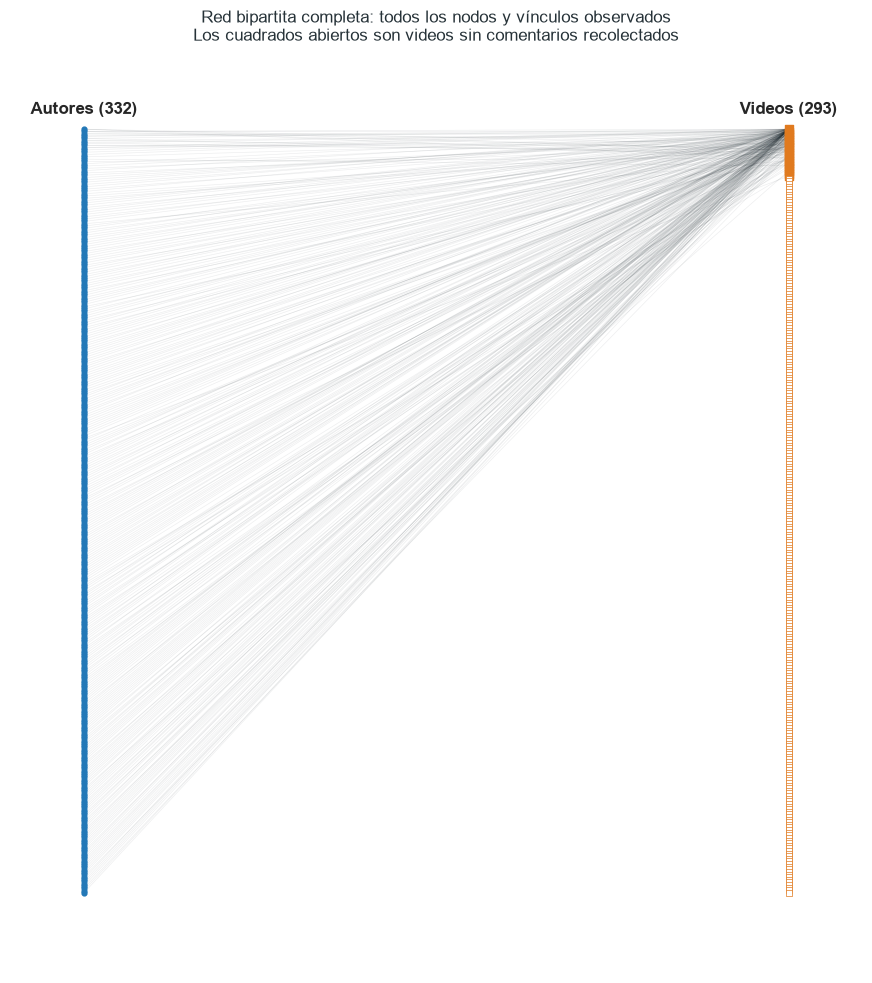

In [25]:
authors_sorted = sorted(author_set, key=lambda node: (G_all.degree(node), node), reverse=True)
videos_sorted = sorted(video_set, key=lambda node: (G_all.degree(node), node), reverse=True)
complete_pos = {
    **{node: (0, 1 - index / max(len(authors_sorted) - 1, 1)) for index, node in enumerate(authors_sorted)},
    **{node: (1, 1 - index / max(len(videos_sorted) - 1, 1)) for index, node in enumerate(videos_sorted)},
}

fig, ax = plt.subplots(figsize=(11, 12))
nx.draw_networkx_edges(G_all, complete_pos, ax=ax, alpha=0.08, width=0.5, edge_color=CHARCOAL)
nx.draw_networkx_nodes(G_all, complete_pos, nodelist=authors_sorted, node_color=BLUE, node_shape="o", node_size=12, ax=ax)
commented_video_nodes = [node for node in videos_sorted if G_all.degree(node) > 0]
uncovered_video_nodes = [node for node in videos_sorted if G_all.degree(node) == 0]
nx.draw_networkx_nodes(G_all, complete_pos, nodelist=commented_video_nodes, node_color=ORANGE, node_shape="s", node_size=28, ax=ax)
nx.draw_networkx_nodes(G_all, complete_pos, nodelist=uncovered_video_nodes, node_color="white", edgecolors=ORANGE, linewidths=0.5, node_shape="s", node_size=13, ax=ax)
ax.text(0, 1.02, "Autores (332)", ha="center", weight="bold")
ax.text(1, 1.02, "Videos (293)", ha="center", weight="bold")
ax.set_title("Red bipartita completa: todos los nodos y vínculos observados\nLos cuadrados abiertos son videos sin comentarios recolectados", color=CHARCOAL)
ax.axis("off")
fig.savefig(FIGURE_DIR / "07_red_bipartita_completa.png", dpi=180, bbox_inches="tight")
plt.show()

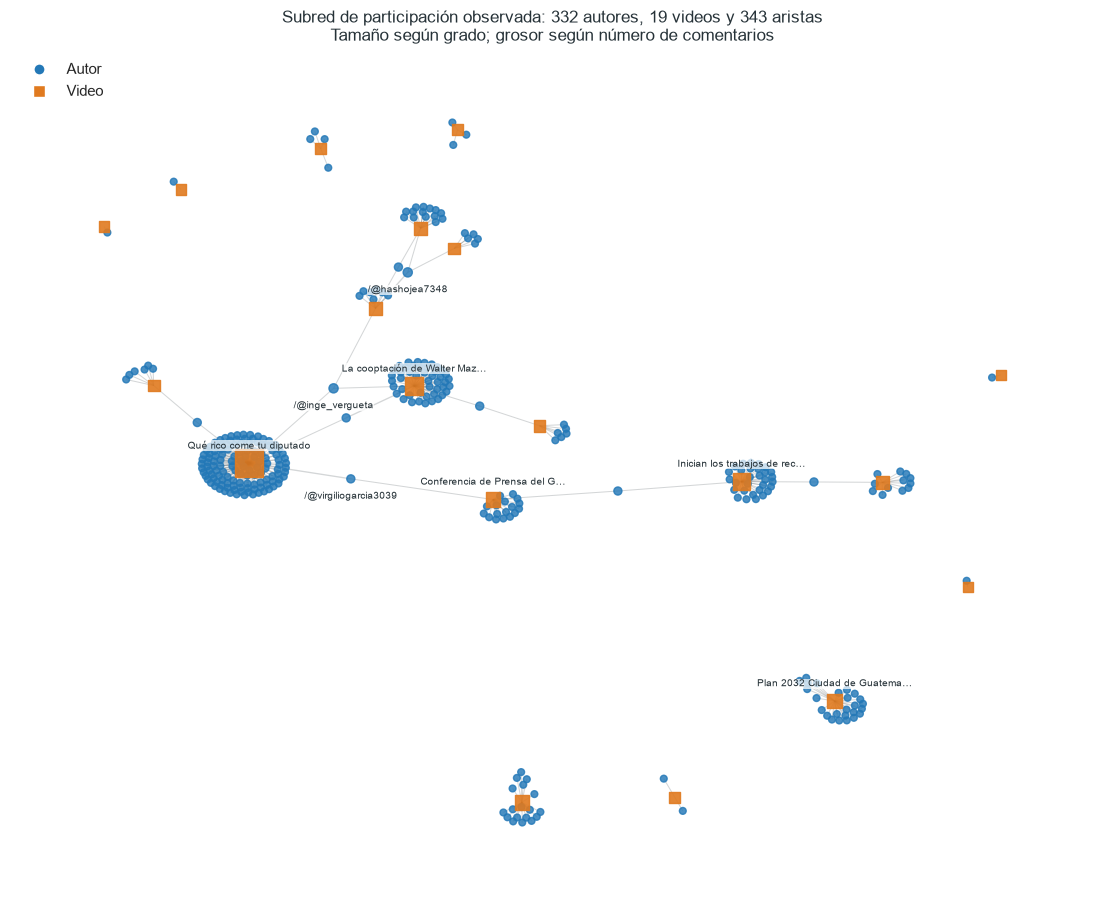

In [26]:
observed_pos = nx.spring_layout(G_observed, seed=RANDOM_SEED, k=0.22, iterations=250, weight="weight")
observed_authors = [node for node in G_observed if G_observed.nodes[node]["node_type"] == "author"]
observed_videos = [node for node in G_observed if G_observed.nodes[node]["node_type"] == "video"]
edge_widths = [0.35 + np.log1p(data["weight"]) * 0.55 for _, _, data in G_observed.edges(data=True)]

fig, ax = plt.subplots(figsize=(14, 11))
nx.draw_networkx_edges(G_observed, observed_pos, width=edge_widths, alpha=0.20, edge_color=CHARCOAL, ax=ax)
nx.draw_networkx_nodes(
    G_observed, observed_pos, nodelist=observed_authors, node_shape="o", node_color=BLUE,
    node_size=[14 + 10 * G_observed.degree(node) for node in observed_authors], alpha=0.82, ax=ax,
)
nx.draw_networkx_nodes(
    G_observed, observed_pos, nodelist=observed_videos, node_shape="s", node_color=ORANGE,
    node_size=[55 + 2.2 * G_observed.degree(node, weight="weight") for node in observed_videos], alpha=0.9, ax=ax,
)
top_video_labels = sorted(
    observed_videos,
    key=lambda node: (G_observed.degree(node), G_observed.degree(node, weight="weight")),
    reverse=True,
)[:5]
top_author_labels = sorted(
    observed_authors,
    key=lambda node: (G_observed.degree(node), G_observed.degree(node, weight="weight")),
    reverse=True,
)[:3]
label_nodes = top_video_labels + top_author_labels
labels = {node: shorten(G_observed.nodes[node]["label"], 28) for node in label_nodes}
label_pos = {
    node: (
        observed_pos[node][0],
        observed_pos[node][1] + (0.045 if node in top_video_labels else -0.045),
    )
    for node in label_nodes
}
nx.draw_networkx_labels(
    G_observed,
    label_pos,
    labels=labels,
    font_size=7,
    font_color=CHARCOAL,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.2},
    ax=ax,
)
legend = [
    Line2D([0], [0], marker="o", color="w", label="Autor", markerfacecolor=BLUE, markersize=8),
    Line2D([0], [0], marker="s", color="w", label="Video", markerfacecolor=ORANGE, markersize=8),
]
ax.legend(handles=legend, frameon=False, loc="upper left")
ax.set_title("Subred de participación observada: 332 autores, 19 videos y 343 aristas\nTamaño según grado; grosor según número de comentarios", color=CHARCOAL)
ax.axis("off")
fig.savefig(FIGURE_DIR / "08_red_bipartita_observada.png", dpi=180, bbox_inches="tight")
plt.show()

### 22. Componentes y candidatos a puente

In [27]:
components = sorted(nx.connected_components(G_observed), key=len, reverse=True)
component_by_node = {node: index + 1 for index, component in enumerate(components) for node in component}
articulation_nodes = list(nx.articulation_points(G_observed))
articulation_authors = [node for node in articulation_nodes if G_observed.nodes[node]["node_type"] == "author"]
articulation_videos = [node for node in articulation_nodes if G_observed.nodes[node]["node_type"] == "video"]

component_rows = []
for index, component in enumerate(components, start=1):
    component_videos = [node.removeprefix("video::") for node in component if node.startswith("video::")]
    component_comments = comments_clean.loc[comments_clean["video_id"].isin(component_videos)]
    terms = ", ".join(term for term, _ in top_tokens(component_comments["texto_limpio"], n=7))
    component_rows.append({
        "componente": index,
        "nodos": len(component),
        "autores": sum(node.startswith("author::") for node in component),
        "videos": len(component_videos),
        "comentarios": len(component_comments),
        "términos_frecuentes": terms,
    })
component_summary = pd.DataFrame(component_rows)

bridge_author_table = pd.DataFrame([
    {
        "node_id": node,
        "label": G_observed.nodes[node]["label"],
        "grado": G_observed.degree(node),
        "grado_ponderado": G_observed.degree(node, weight="weight"),
        "componente": component_by_node[node],
    }
    for node in articulation_authors
]).sort_values(["grado", "grado_ponderado"], ascending=False)

display(component_summary.head(10))
display(bridge_author_table)
print(f"Componentes conexos observados: {len(components)}")
print(f"Puntos de articulación: {len(articulation_nodes)} ({len(articulation_authors)} autores y {len(articulation_videos)} videos)")

,componente,nodos,autores,videos,comentarios,términos_frecuentes
0,1,286,276,10,343,"pueblo, diputado, él, pagar, dinero, presidente, corrupto"
1,2,26,25,1,25,"guatemala, ciudad, saludo, proyecto, vivir, tiempo, cuidad"
2,3,19,18,1,25,"you, país, deportar, entrar, pais, persona, pasar"
3,4,5,4,1,4,"iniciativa, juego, excelente, ver, deporte, dinamico, entretenido"
4,5,4,3,1,3,"guatemala, cambiar, dictadura, año, ver, semilla, bernardo"
5,6,3,2,1,2,"persona, encargado, ecosistema, ayudar, problema, recuerdo, dejar"
6,7,2,1,1,1,wooow
7,8,2,1,1,1,"teléfono, subscribir, boletín, informativo, intentar, pagina, web"
8,9,2,1,1,1,
9,10,2,1,1,1,"gracias, video, importante, tipo, espacio"


,node_id,label,grado,grado_ponderado,componente
2,author::UCvcu1kR8xMYy_I1Ty-2mV2Q,/@hashojea7348,3,4,1
3,author::UCpsKOkt5iWTbenzeuq7dsmQ,/@inge_vergueta,3,3,1
5,author::UCHTGCgY2l-DQJIvlA_cpa_Q,/@virgiliogarcia3039,2,3,1
0,author::UCjZgFEowMBrsjodqfovzdKw,/@franciscoflores3120,2,2,1
1,author::UCdFlugHJJa4l3YqWuNRmvXw,/@MarcosCarillo-b1r,2,2,1
4,author::UCsUCN0Yq_UyTvKjOJLmNrnQ,/@moisesvaldez4043,2,2,1
6,author::UCzZ6dDCEsLMXbc5pCFXIprw,/@josegil3813,2,2,1


Componentes conexos observados: 10
Puntos de articulación: 22 (7 autores y 15 videos)


### 23. Interpretación final del avance

In [28]:
largest_component_share = len(components[0]) / G_observed.number_of_nodes()
display(Markdown(f'''
**Significado de una arista.** Una arista no dirigida indica exclusivamente que un autor publicó al menos un comentario principal en un video de la muestra. Su peso es el número de comentarios de ese autor en ese video. No representa amistad, respuesta directa, aprobación, suscripción ni relación personal.

**Estructura preliminar.** La subred observada tiene {len(components)} componentes; la mayor contiene {len(components[0])} nodos ({largest_component_share:.1%} de la subred). Se identifican {len(articulation_authors)} autores como puntos de articulación, pero esta es una verificación preliminar de desconexión, no el análisis completo de centralidad del ejercicio 8.

**Cobertura.** Los {len(zero_degree_videos)} videos con grado cero no deben describirse como contenido sin audiencia. Solo se sabe que no tienen comentarios en el archivo entregado. Además, los comentarios proceden de 19 de los 293 videos y los conteos corresponden al momento de recolección.

**Alcance.** Los componentes conexos no se denominan comunidades. Louvain/Leiden, modularidad y sentimiento formal quedan reservados para los ejercicios 7 y 9. Los resultados describen la muestra y no se generalizan a todos los usuarios de YouTube ni a Guatemala.
'''))

component_summary.to_csv(TABLE_DIR / "componentes_preliminares.csv", index=False, encoding="utf-8-sig")
bridge_author_table.to_csv(TABLE_DIR / "autores_puente_preliminares.csv", index=False, encoding="utf-8-sig")
final_expected = [
    TABLE_DIR / "nodos_autor_video.csv",
    TABLE_DIR / "aristas_autor_video.csv",
    GRAPH_DIR / "red_autor_video.graphml",
    FIGURE_DIR / "07_red_bipartita_completa.png",
    FIGURE_DIR / "08_red_bipartita_observada.png",
]
assert all(path.exists() for path in final_expected)
print("Actividad 4 completada y artefactos verificados.")


**Significado de una arista.** Una arista no dirigida indica exclusivamente que un autor publicó al menos un comentario principal en un video de la muestra. Su peso es el número de comentarios de ese autor en ese video. No representa amistad, respuesta directa, aprobación, suscripción ni relación personal.

**Estructura preliminar.** La subred observada tiene 10 componentes; la mayor contiene 286 nodos (81.5% de la subred). Se identifican 7 autores como puntos de articulación, pero esta es una verificación preliminar de desconexión, no el análisis completo de centralidad del ejercicio 8.

**Cobertura.** Los 274 videos con grado cero no deben describirse como contenido sin audiencia. Solo se sabe que no tienen comentarios en el archivo entregado. Además, los comentarios proceden de 19 de los 293 videos y los conteos corresponden al momento de recolección.

**Alcance.** Los componentes conexos no se denominan comunidades. Louvain/Leiden, modularidad y sentimiento formal quedan reservados para los ejercicios 7 y 9. Los resultados describen la muestra y no se generalizan a todos los usuarios de YouTube ni a Guatemala.


Actividad 4 completada y artefactos verificados.


## Conclusiones

El avance cubre las actividades 1–4 con trazabilidad desde los archivos crudos hasta las tablas y figuras. La integración es íntegra, la limpieza conserva auditoría y la red mantiene todos los nodos del catálogo. El hallazgo metodológico central es que la cobertura de comentarios es limitada y muy concentrada; por ello se distinguen cuidadosamente participación observada, falta de cobertura y relaciones sociales no medidas.